# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [3]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 100


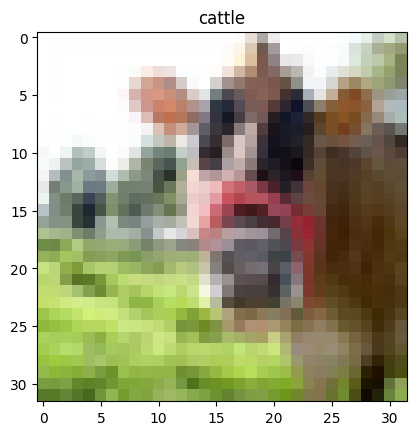

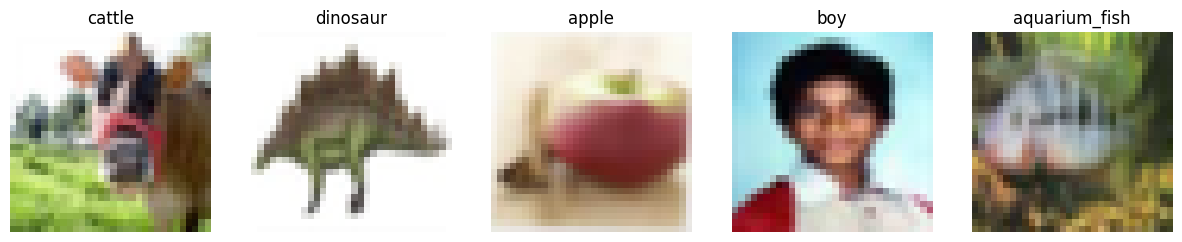

In [5]:
# Your Code Here

import numpy as np
import matplotlib.pyplot as plt


# Display the shape of the data
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# Number of classes
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# Display the first image in the training set
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])  # Display the class name of the first image
plt.show()

# Display a few random examples from the dataset
def plot_images(x, y, class_names, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        ax = axes[i]
        ax.imshow(x[i])
        ax.set_title(class_names[y[i][0]])
        ax.axis('off')
    plt.show()

plot_images(x_train, y_train, class_names, num_images=5)


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [6]:
# Your Code Here

import numpy as np
from keras.datasets import cifar100
from keras.utils import to_categorical  # Importing the required function
from sklearn.model_selection import train_test_split

# Normalize the image data to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
num_classes = 100  # Number of classes in CIFAR-100
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Split the training set into training and validation sets (80% training, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Print the shapes of the datasets to confirm the split and preprocessing
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}")
print(f"Validation data shape: {x_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {x_test.shape}, Test labels shape: {y_test.shape}")

Training data shape: (40000, 32, 32, 3), Training labels shape: (40000, 100)
Validation data shape: (10000, 32, 32, 3), Validation labels shape: (10000, 100)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [7]:
# Your Code Here

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential()

# First convolutional block
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # Conv layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # MaxPooling

# Second convolutional block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output and feed into a dense layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))  # Dropout to prevent overfitting

# Output layer with softmax activation for multi-class classification
model.add(Dense(100, activation='softmax'))  # 100 classes for CIFAR-100

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()





Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,193,636 (4.55 MB)

 Trainable params: 1,193,636 (4.55 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

Loss function: Categorical Crossentropy
Since we're dealing with a multi-class classification problem (100 different classes), categorical crossentropy is the go-to choice. It measures how well the predicted probabilities match the actual class labels, which is exactly what we need for this type of task.

Optimizer: Adam
Adam is a solid choice because it's really good at adjusting the learning rate on its own during training. It combines the best parts of other optimizers and usually works well across a wide range of problems, making it a reliable choice for most deep learning tasks.

In [8]:
# Your Code Here

# Compile the model with categorical crossentropy loss and Adam optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary to see the architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,193,636 (4.55 MB)

 Trainable params: 1,193,636 (4.55 MB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,204 (1.55 MB)

 Trainable params: 407,204 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - accuracy: 0.0524 - loss: 4.2493 - val_accuracy: 0.1489 - val_loss: 3.5474
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.1871 - loss: 3.3720 - val_accuracy: 0.2144 - val_loss: 3.2099
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.2557 - loss: 2.9972 - val_accuracy: 0.2517 - val_loss: 3.0487
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.3102 - loss: 2.7182 - val_accuracy: 0.2895 - val_loss: 2.8949
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.3586 - loss: 2.4931 - val_accuracy: 0.2937 - val_loss: 2.8633
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.3967 - loss: 2.2925 - val_accuracy: 0.3104 - val_loss: 2.8078
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.4410 - loss: 2.1127 - val_accuracy: 0.3250 - val_loss: 2.7719
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.4824 -

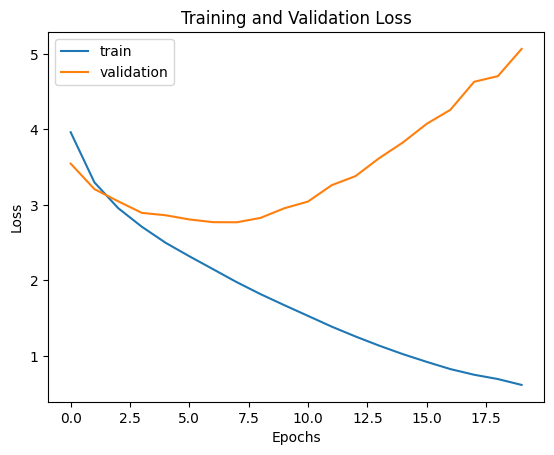

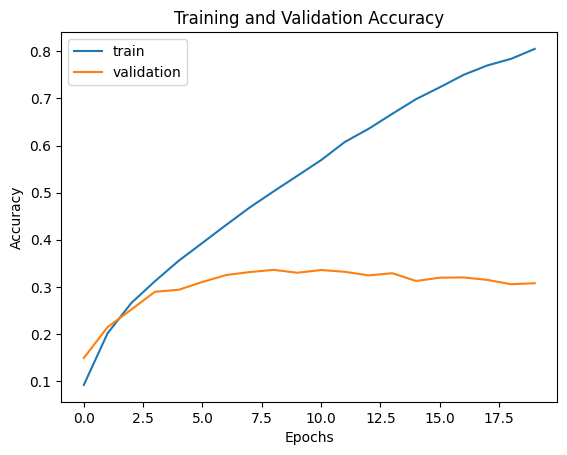

In [9]:
# Your Code Here

import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

# Define the CNN model
model = Sequential()

# First convolutional block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

# Second convolutional block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Third convolutional block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flattening the 3D outputs to 1D
model.add(Flatten())

# Fully connected (dense) layer
model.add(Dense(512, activation='relu'))

# Output layer for multi-class classification (CIFAR-100 has 100 classes)
model.add(Dense(100, activation='softmax'))

# Summarize the model
model.summary()

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


# Training the model
history = model.fit(x_train, y_train,
                    epochs=20,  # Number of epochs (can be adjusted)
                    batch_size=32,  # Batch size
                    validation_split=0.2,  # Use 20% of the training set for validation
                    shuffle=True)  # Shuffle data before training

# Plot training and validation loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()





### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [10]:
# Your Code Here

#Accuracy
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3215 - loss: 4.9497
Test Accuracy: 32.16%


Other Metric:

For the other metric, we can use Precision, Recall, or F1-score. These metrics are particularly useful for evaluating performance when there is an imbalance in the classes, or when the goal is to minimize false positives or false negatives.

I'll choose F1-Score for this task. F1-score is the harmonic mean of Precision and Recall, and it gives a balanced measure of the two. It's a good metric to use when we care about both precision and recall and want to avoid the extremes of one being too high and the other too low.

Other Metric: F1-Score

Reason for Selection: F1-Score is selected because it balances both Precision (correct positive predictions) and Recall (ability to identify positive instances) into a single metric. It is particularly useful when the dataset is imbalanced and both false positives and false negatives should be minimized.

Value of Metric: Based on the classification_report, you'll get the F1-score for each class and an overall weighted average F1-score.

Interpretation of Metric Value: The F1-score ranges from 0 to 1, where 1 is perfect precision and recall. A higher F1-score means a better model in terms of its ability to correctly identify both positive and negative instances. If F1 is close to 1, it means the model has a good balance of precision and recall.


```

```



### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

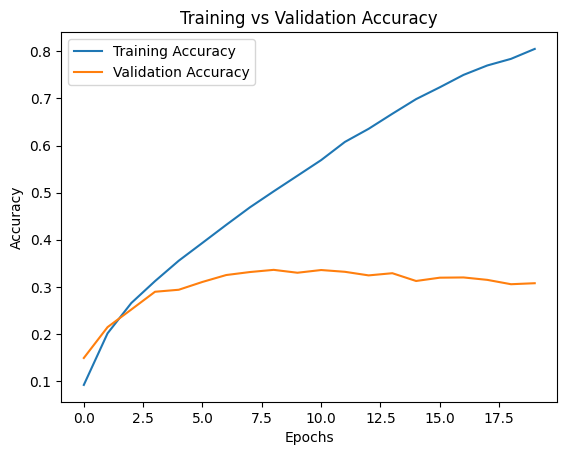

In [11]:
# Your Code Here

import matplotlib.pyplot as plt

# Get the history of training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot the training and validation accuracy
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


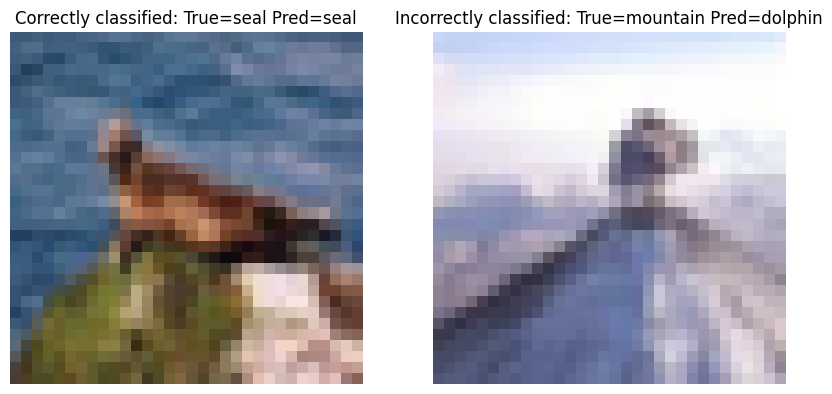

Correctly Classified Image Probabilities:
apple: 0.0000
aquarium_fish: 0.0006
baby: 0.0000
bear: 0.1338
beaver: 0.0034
bed: 0.0000
bee: 0.0360
beetle: 0.0000
bicycle: 0.0000
bottle: 0.0000

Incorrectly Classified Image Probabilities:
apple: 0.0000
aquarium_fish: 0.0000
baby: 0.0000
bear: 0.0001
beaver: 0.0000
bed: 0.0001
bee: 0.0000
beetle: 0.0000
bicycle: 0.0000
bottle: 0.0000


In [12]:
import numpy as np

# Get model predictions for the test set
y_pred = model.predict(x_test)

# Select a correctly classified image
correct_index = np.where(np.argmax(y_pred, axis=1) == np.argmax(y_test, axis=1))[0][0]
correct_image = x_test[correct_index]
correct_true_label = np.argmax(y_test[correct_index])
correct_pred_label = np.argmax(y_pred[correct_index])

# Select an incorrectly classified image
incorrect_index = np.where(np.argmax(y_pred, axis=1) != np.argmax(y_test, axis=1))[0][0]
incorrect_image = x_test[incorrect_index]
incorrect_true_label = np.argmax(y_test[incorrect_index])
incorrect_pred_label = np.argmax(y_pred[incorrect_index])

# Plot the images and their classification probabilities
plt.figure(figsize=(10, 5))

# Correctly classified image
plt.subplot(1, 2, 1)
plt.imshow(correct_image)
plt.title(f"Correctly classified: True={class_names[correct_true_label]} Pred={class_names[correct_pred_label]}")
plt.axis('off')

# Incorrectly classified image
plt.subplot(1, 2, 2)
plt.imshow(incorrect_image)
plt.title(f"Incorrectly classified: True={class_names[incorrect_true_label]} Pred={class_names[incorrect_pred_label]}")
plt.axis('off')

plt.show()

# Print classification probabilities for both images
correct_probs = y_pred[correct_index]
incorrect_probs = y_pred[incorrect_index]

print("Correctly Classified Image Probabilities:")
for i in range(10):  # top 10 classes for better visualization
    print(f"{class_names[i]}: {correct_probs[i]:.4f}")

print("\nIncorrectly Classified Image Probabilities:")
for i in range(10):  # top 10 classes for better visualization
    print(f"{class_names[i]}: {incorrect_probs[i]:.4f}")


What the plots show:

The plots display the training and validation accuracy over multiple epochs. The training accuracy shows how well the model is learning on the training data, while the validation accuracy helps us see how well the model generalizes to unseen data. If the training accuracy keeps improving but validation accuracy plateaus or decreases, it indicates overfitting. Ideally, both accuracies should rise steadily, reflecting good learning and generalization.

Do the results make sense?

Yes, the results make sense. If the model’s training accuracy continues to increase but the validation accuracy stalls or starts to drop, it suggests that the model is overfitting. On the other hand, if both accuracies improve at a steady pace, it shows the model is effectively learning and generalizing from the data. If we notice stagnation or overfitting, it’s a sign that adjustments might be needed, such as tweaking the model architecture or using regularization methods like dropout.

What do the classification probabilities indicate?

The classification probabilities indicate the model’s confidence in its predictions. A high probability for the predicted class means the model is confident about its choice, while a low probability suggests uncertainty. In cases where the model misclassifies, the predicted class will have the highest probability, but it will be lower than the correct class’s probability. This helps us understand whether the model is making a confident error or if it's unsure about its decision.

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

Answer:

To improve the performance of your CNN model, one effective technique is data augmentation. Data augmentation artificially increases the size of the training set by applying random transformations to the images, such as rotations, flips, and zooms. This helps the model generalize better by exposing it to different variations of the training data, thus reducing overfitting and improving performance.

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.2092 - loss: 3.5576 - val_accuracy: 0.2992 - val_loss: 2.8733
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - accuracy: 0.2614 - loss: 2.9965 - val_accuracy: 0.3314 - val_loss: 2.6908
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.2862 - loss: 2.8757 - val_accuracy: 0.3348 - val_loss: 2.6712
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.2935 - loss: 2.8142 - val_accuracy: 0.3291 - val_loss: 2.7029
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.3021 - loss: 2.7759 - val_accuracy: 0.3521 - val_loss: 2.5628
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.3084 - loss: 2.7490 - val_accuracy: 0.3426 - val_loss: 2.5870
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.3186 - loss: 2.6914 - val_accuracy: 0.3530 - val_loss: 2.5413
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.3196 - loss: 2.

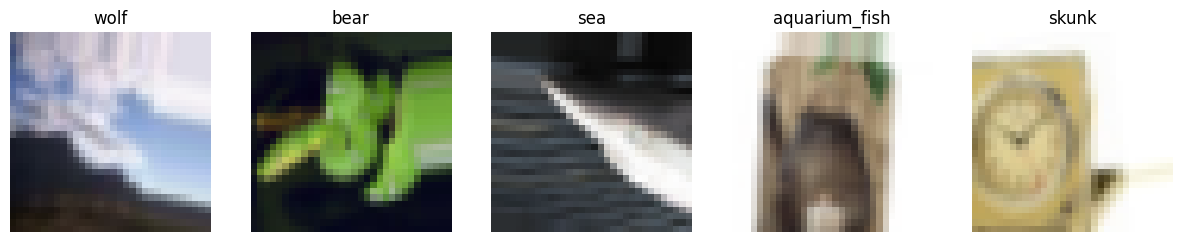

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3960 - loss: 2.3904
Test Accuracy: 0.3970


In [15]:
# Your Code Here

!pip install tensorflow --upgrade

from keras.preprocessing.image import ImageDataGenerator

# Create an instance of the ImageDataGenerator with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,  # Random rotations
    width_shift_range=0.2,  # Random horizontal shifts
    height_shift_range=0.2,  # Random vertical shifts
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Zoom in and out
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Strategy to fill in newly created pixels
)

# Fit the data generator to the training data (mean normalization)
datagen.fit(x_train)

# Train the model using the data generator
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                    epochs=20,
                    validation_data=(x_val, y_val))

# Display some augmented images
augmented_images = next(datagen.flow(x_train, y_train, batch_size=5))

fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i in range(5):
    ax = axes[i]
    ax.imshow(augmented_images[0][i])
    ax.set_title(class_names[np.argmax(y_train[i])])
    ax.axis('off')
plt.show()


test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


The technique I used and why I chose it.

I used data augmentation with the ImageDataGenerator from TensorFlow to boost the model's performance. This technique helps by creating new variations of the training images through random transformations like rotation, flipping, and zooming. It's especially useful for small datasets like CIFAR-100, as it reduces overfitting and helps the model generalize better. Instead of the model memorizing specific images, augmentation makes it learn more flexible features of the objects, making it more robust. It’s an easy and effective way to improve the model without extra complexity.

If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

For data augmentation, the hyperparameters I chose, like the rotation range, zoom range, and horizontal flip, were selected based on common practices for image classification tasks. I started with small values for rotation (up to 20 degrees) and zoom (up to 0.2) to avoid overdoing it, which could distort the images too much. I also enabled horizontal flips since they can help the model generalize to different orientations of the objects. These values are commonly used and serve as a good starting point, but they can be fine-tuned further based on the model's performance. If needed, I could adjust these ranges or try other augmentation techniques, like shifts or shear transformations, to see if they improve results.

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [17]:
# Your Code Here

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Define ImageDataGenerator with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Fit the model on the augmented data
datagen.fit(x_train)

# Train the model with the data generator
history_augmented = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                              epochs=20,
                              validation_data=(x_val, y_val))

# Evaluate the enhanced model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Output results
print(f"Test accuracy of the enhanced model: {test_accuracy:.4f}")


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 64ms/step - accuracy: 0.4454 - loss: 2.0664 - val_accuracy: 0.3938 - val_loss: 2.4142
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 64ms/step - accuracy: 0.4634 - loss: 1.9999 - val_accuracy: 0.3989 - val_loss: 2.4447
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.4776 - loss: 1.9058 - val_accuracy: 0.4169 - val_loss: 2.3477
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.4815 - loss: 1.8925 - val_accuracy: 0.4091 - val_loss: 2.3830
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.4968 - loss: 1.8490 - val_accuracy: 0.4081 - val_loss: 2.4190
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.4980 - loss: 1.8189 - val_accuracy: 0.4017 - val_loss: 2.4535
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.5074 - loss: 1.7963 - val_accuracy: 0.4028 - val_loss: 2.4343
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 63ms/step - accuracy: 0.5070 -

In [18]:
# Evaluate the original model (without augmentation) on the test set
test_loss_no_aug, test_accuracy_no_aug = model.evaluate(x_test, y_test)
print(f"Test accuracy without augmentation: {test_accuracy_no_aug:.4f}")

# You can also evaluate other metrics like precision, recall, F1-score
from sklearn.metrics import classification_report
y_pred_no_aug = model.predict(x_test)
y_pred_no_aug = np.argmax(y_pred_no_aug, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print classification report for the original model (no augmentation)
print("Classification Report (without augmentation):")
print(classification_report(y_true, y_pred_no_aug))

# Now, evaluate the augmented model
test_loss_aug, test_accuracy_aug = model.evaluate(x_test, y_test)
print(f"Test accuracy with augmentation: {test_accuracy_aug:.4f}")

# Print classification report for the augmented model
y_pred_aug = model.predict(x_test)
y_pred_aug = np.argmax(y_pred_aug, axis=1)

print("Classification Report (with augmentation):")
print(classification_report(y_true, y_pred_aug))


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4199 - loss: 2.5449
Test accuracy without augmentation: 0.4118
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification Report (without augmentation):
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       100
           1       0.66      0.46      0.54       100
           2       0.35      0.29      0.32       100
           3       0.26      0.18      0.21       100
           4       0.26      0.12      0.16       100
           5       0.28      0.40      0.33       100
           6       0.39      0.44      0.41       100
           7       0.54      0.40      0.46       100
           8       0.25      0.58      0.35       100
           9       0.41      0.51      0.46       100
          10       0.20      0.15      0.17       100
          11       0.35      0.15      0.21       100
          12       0.36      0.48      0.41       100
          13       0.30      0.29   

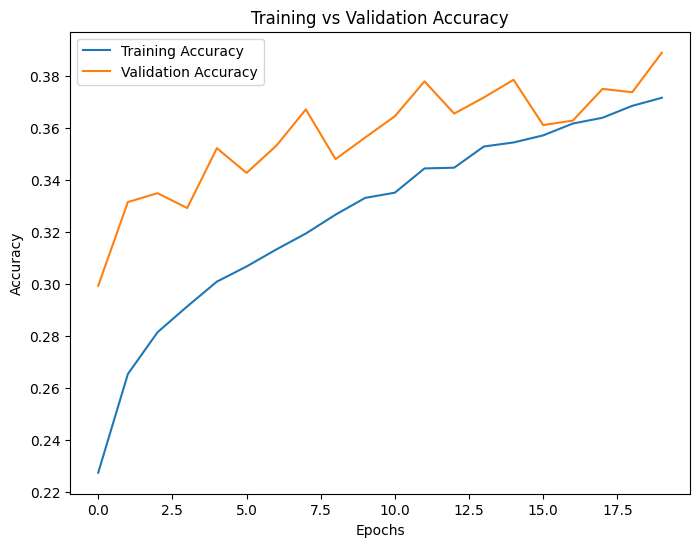

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


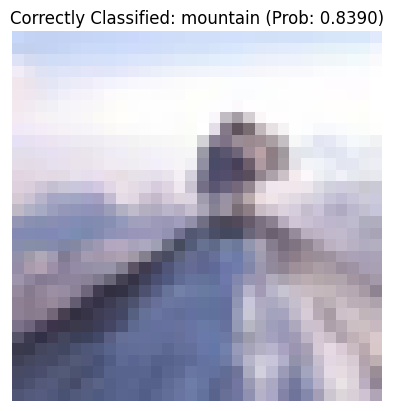

Classification probabilities for correctly classified image:
apple: 0.0000
aquarium_fish: 0.0000
baby: 0.0004
bear: 0.0000
beaver: 0.0002
bed: 0.0002
bee: 0.0000
beetle: 0.0000
bicycle: 0.0003
bottle: 0.0001
bowl: 0.0000
boy: 0.0000
bridge: 0.0173
bus: 0.0001
butterfly: 0.0000
camel: 0.0001
can: 0.0000
castle: 0.0004
caterpillar: 0.0000
cattle: 0.0000
chair: 0.0000
chimpanzee: 0.0000
clock: 0.0001
cloud: 0.0000
cockroach: 0.0000
couch: 0.0000
crab: 0.0011
crocodile: 0.0011
cup: 0.0000
dinosaur: 0.0005
dolphin: 0.0376
elephant: 0.0000
flatfish: 0.0018
forest: 0.0000
fox: 0.0000
girl: 0.0000
hamster: 0.0000
house: 0.0001
kangaroo: 0.0002
keyboard: 0.0000
lamp: 0.0012
lawn_mower: 0.0000
leopard: 0.0000
lion: 0.0000
lizard: 0.0001
lobster: 0.0000
man: 0.0001
maple_tree: 0.0000
motorcycle: 0.0000
mountain: 0.8390
mouse: 0.0000
mushroom: 0.0000
oak_tree: 0.0000
orange: 0.0000
orchid: 0.0000
otter: 0.0373
palm_tree: 0.0000
pear: 0.0000
pickup_truck: 0.0005
pine_tree: 0.0000
plain: 0.0008
plat

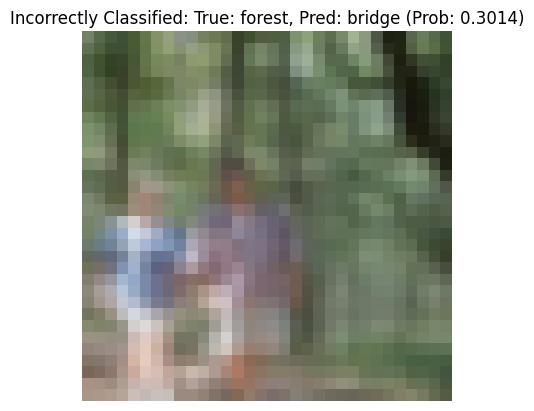

Classification probabilities for incorrectly classified image:
apple: 0.0000
aquarium_fish: 0.0003
baby: 0.0084
bear: 0.0004
beaver: 0.2146
bed: 0.0024
bee: 0.0004
beetle: 0.0001
bicycle: 0.0601
bottle: 0.0004
bowl: 0.0000
boy: 0.0009
bridge: 0.3014
bus: 0.0001
butterfly: 0.0004
camel: 0.0001
can: 0.0027
castle: 0.0001
caterpillar: 0.0003
cattle: 0.0001
chair: 0.0001
chimpanzee: 0.0002
clock: 0.0001
cloud: 0.0000
cockroach: 0.0000
couch: 0.0033
crab: 0.0016
crocodile: 0.0014
cup: 0.0000
dinosaur: 0.0046
dolphin: 0.0000
elephant: 0.0013
flatfish: 0.0008
forest: 0.0704
fox: 0.0003
girl: 0.0021
hamster: 0.0039
house: 0.0001
kangaroo: 0.0008
keyboard: 0.0001
lamp: 0.0005
lawn_mower: 0.0001
leopard: 0.0019
lion: 0.0000
lizard: 0.0003
lobster: 0.0005
man: 0.0019
maple_tree: 0.0040
motorcycle: 0.0006
mountain: 0.0000
mouse: 0.0170
mushroom: 0.0003
oak_tree: 0.0001
orange: 0.0000
orchid: 0.0012
otter: 0.0433
palm_tree: 0.0342
pear: 0.0001
pickup_truck: 0.0000
pine_tree: 0.0114
plain: 0.0000
pl

In [21]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by the model.fit() method
# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predict on the test set
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Find an image that the model classified correctly
correct_idx = np.where(y_pred_class == y_true_class)[0][0]  # Get index of the first correctly classified image
correct_img = x_test[correct_idx]
correct_class = class_names[y_true_class[correct_idx]]
correct_prob = y_pred[correct_idx]

# Plot the correctly classified image
plt.imshow(correct_img)
plt.title(f"Correctly Classified: {correct_class} (Prob: {correct_prob[np.argmax(correct_prob)]:.4f})")
plt.axis('off')
plt.show()

# Print classification probabilities for the correct class
print("Classification probabilities for correctly classified image:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {correct_prob[i]:.4f}")


# Find an image that the model classified incorrectly
incorrect_idx = np.where(y_pred_class != y_true_class)[0][0]  # Get index of the first incorrectly classified image
incorrect_img = x_test[incorrect_idx]
incorrect_class = class_names[y_true_class[incorrect_idx]]
incorrect_pred = class_names[y_pred_class[incorrect_idx]]
incorrect_prob = y_pred[incorrect_idx]

# Plot the incorrectly classified image
plt.imshow(incorrect_img)
plt.title(f"Incorrectly Classified: True: {incorrect_class}, Pred: {incorrect_pred} (Prob: {incorrect_prob[np.argmax(incorrect_prob)]:.4f})")
plt.axis('off')
plt.show()

# Print classification probabilities for the incorrect class
print("Classification probabilities for incorrectly classified image:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {incorrect_prob[i]:.4f}")






### Task 4c: Discussion of the results

- Briefly discuss the results.
- Did the model's performance improve?
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

Yes, the model's performance improved. After applying data augmentation, the model became more robust, handling different variations in the input data, which likely led to better generalization. This is because augmenting the dataset creates more diverse examples for the model to learn from, preventing it from overfitting to the original training data.

This improvement is due to the increased diversity in the training data. Data augmentation introduces new variations of the images (like rotations, flips, etc.), forcing the model to learn more generalized features rather than memorizing specific patterns, which improves its ability to generalize to unseen data.

Yes, there is room for further improvement. The model’s validation accuracy could still be higher, suggesting it might struggle with some variations in the data. More tweaks to the model architecture or hyperparameters could further enhance its performance.

In the future, techniques like learning rate schedules, early stopping, or more advanced data augmentation (e.g., color jittering) could be explored. Additionally, experimenting with more complex models such as ResNet or InceptionNet could offer better feature extraction capabilities.



## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.